# Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import Lasso, LassoCV, ElasticNetCV, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import xgboost as xgb
import lightgbm as lgb

import json
import time
import os

sns.set_style('darkgrid')
magma_palette = sns.color_palette('magma', 6)
plt.rcParams['figure.figsize'] = (15, 6)

tf.get_logger().setLevel('ERROR')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)



## Data Loading and Exploration

In [2]:
df = pd.read_csv('Data/processed_dataset.csv', parse_dates=['Date'], index_col='Date')

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

TARGET_COLUMN = 'food_price_index'

EXOGENOUS_FEATURES = [
    'market_price_maize', 'market_price_rice', 'market_price_sorghum',
    'market_price_oil', 'climate_temperature', 'climate_precipitation',
    'climate_humidity', 'population', 'conflict_critical',
    'conflict_heightened', 'conflict_typical', 'drought_ndvi_critical',
    'drought_ndvi_heightened', 'drought_ndvi_typical',
    'drought_rainfall_critical', 'drought_rainfall_heightened',
    'drought_rainfall_typical', 'exchange_rate_critical',
    'exchange_rate_heightened', 'exchange_rate_typical',
    'food_price_critical', 'food_price_heightened', 'food_price_typical',
    'fuel_price_critical', 'fuel_price_heightened', 'fuel_price_typical',
    'risk_population_estimated', 'risk_population_percentage',
    'heavy_rainfall_critical', 'heavy_rainfall_heightened',
    'heavy_rainfall_typical', 'cpi_alcohol_tobacco_narcotics',
    'cpi_clothing_footwear', 'cpi_communication', 'cpi_education',
    'cpi_food_non_alcoholic_beverages', 'cpi_furnishings_household_maintenance',
    'cpi_health', 'cpi_housing_utilities', 'cpi_miscellaneous',
    'cpi_recreation_culture', 'cpi_restaurants_hotels', 'cpi_transport',
    'exchange_rate', 'gdp_per_capita_usd', 'government_final_consumption',
    'gross_fixed_capital_formation', 'household_final_consumption',
    'imports_goods_services', 'month', 'year', 'quarter'
]

print(f"\nTarget variable: {TARGET_COLUMN}")
print(f"Number of features: {len(EXOGENOUS_FEATURES)}")

print("\nMissing values in features:")
missing_counts = df[EXOGENOUS_FEATURES].isnull().sum()
missing_features = missing_counts[missing_counts > 0]
if len(missing_features) > 0:
    for feat, count in missing_features.items():
        print(f"  - {feat}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("  No missing values found")



Dataset shape: (5778, 57)
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Total missing values: 360

Target variable: food_price_index
Number of features: 52

Missing values in features:
  - climate_temperature: 120 (2.08%)
  - climate_precipitation: 120 (2.08%)
  - climate_humidity: 120 (2.08%)


In [3]:
climate_missing = df[df[['climate_temperature', 'climate_precipitation', 'climate_humidity']].isnull().any(axis=1)]
climate_missing

,adm1_name,adm2_name,mkt_name,market_price_maize,market_price_rice,market_price_sorghum,market_price_oil,food_price_index,population,climate_temperature,...,cpi_transport,exchange_rate,gdp_per_capita_usd,government_final_consumption,gross_fixed_capital_formation,household_final_consumption,imports_goods_services,month,year,quarter
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,Market Average,Market Average,Market Average,7032.11,14004.08,6830.65,37480.72,0.91,192447.0,NaN,...,3.988219,22285.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,1,2015,1
2015-02-01,Market Average,Market Average,Market Average,6868.20,13732.85,6316.60,37277.02,0.90,192447.0,NaN,...,3.950615,22196.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,2,2015,1
2015-03-01,Market Average,Market Average,Market Average,7079.62,13807.81,6119.27,37080.42,0.90,192447.0,NaN,...,3.950615,22211.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,3,2015,1
2015-04-01,Market Average,Market Average,Market Average,7063.34,13942.59,6208.19,36885.77,0.90,192447.0,NaN,...,3.969913,22232.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,4,2015,2
2015-05-01,Market Average,Market Average,Market Average,7016.91,14013.36,5908.61,36650.26,0.89,192447.0,NaN,...,3.862924,22265.0,414.263094,324289767.7,6.746279e+08,7.281761e+09,3.987255e+09,5,2015,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,Market Average,Market Average,Market Average,10451.71,23064.41,12010.83,49798.57,1.41,192447.0,NaN,...,5.282194,28043.0,502.000000,677000000.0,1.244000e+09,1.072000e+10,6.544000e+09,8,2024,3
2024-09-01,Market Average,Market Average,Market Average,10104.78,23503.49,11375.56,49965.73,1.39,192447.0,NaN,...,5.282194,26976.0,502.000000,677000000.0,1.244000e+09,1.072000e+10,6.544000e+09,9,2024,3
2024-10-01,Market Average,Market Average,Market Average,9939.93,23411.01,11312.95,49969.98,1.38,192447.0,NaN,...,5.282194,28092.0,502.000000,677000000.0,1.244000e+09,1.072000e+10,6.544000e+09,10,2024,4


In [4]:
#count how many markets are in adm2_name
markets_per_adm2 = df.groupby('adm2_name')['mkt_name'].nunique().reset_index()
markets_per_adm2.columns = ['adm2_name', 'num_markets']
print("\nNumber of markets per ADM2 region:")
print(markets_per_adm2)


Number of markets per ADM2 region:
         adm2_name  num_markets
0          Afgooye            1
1          Afmadow            1
2           Balcad            1
3          Banadir            2
4         Baydhaba            1
5      Belet Weyne            1
6      Belet Xaawo            1
7          Berbera            1
8           Borama            1
9          Bossaso            1
10         Bu'aale            1
11      Bulo Burto            1
12           Burco            1
13        Burtinle            1
14       Cabudwaaq            1
15         Cadaado            1
16          Cadale            1
17      Ceel Barde            1
18       Ceel Waaq            1
19      Ceerigaabo            1
20   Dhuusamarreeb            1
21        Diinsoor            1
22          Doolow            1
23             Eyl            1
24       Gaalkacyo            1
25         Garoowe            1
26        Hargeysa            1
27           Hobyo            1
28       Jalalaqsi            1
29  

In [5]:
#Rename adm1_name to region and mkt_name to district, and drop adm2_name
df.rename(columns={'adm1_name': 'region', 'mkt_name': 'district'}, inplace=True)
df.drop(columns=['adm2_name'], inplace=True)

EXOGENOUS_FEATURES = ['region', 'district'] + EXOGENOUS_FEATURES

In [6]:
df_clean = df.dropna()
df_clean = df_clean.sort_index()
print(f"\nCleaned dataset shape (after dropping missing values): {df_clean.shape}")


Cleaned dataset shape (after dropping missing values): (5658, 56)


## Splitting Train and Validation Sets

In [7]:
train_size = int(len(df_clean) * 0.90)
train_df = df_clean.iloc[:train_size].copy()
test_df = df_clean.iloc[train_size:].copy()

print(f"\nTraining set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print(f"Train date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"Test date range: {test_df.index.min()} to {test_df.index.max()}")


Training set size: 5092
Test set size: 566
Train date range: 2015-01-01 00:00:00 to 2023-12-01 00:00:00
Test date range: 2023-12-01 00:00:00 to 2024-12-01 00:00:00


## Feature Engineering

The engineered features are crucial for a robust time series model: 

*   **Time-based features** (month, quarter) will help the model capture recurring seasonal patterns in food prices. 

*   **Lagged features** capture the autocorrelation, allowing the model to predict the current price based on recent past prices in the same region. 

*   **Rolling statistics** provide a smoothed trend, which can help stabilize the model and capture short-term volatility.


In [8]:
def add_lags(data, target_col, lags=[1, 3, 6]):
    for lag in lags:
        data[f'{target_col}_lag_{lag}'] = data[target_col].shift(lag)
    data[f'{target_col}_rolling_mean_3'] = data[target_col].rolling(window=3).mean()
    return data

train_df = add_lags(train_df, TARGET_COLUMN)
test_df = add_lags(test_df, TARGET_COLUMN)

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

LAG_FEATURES = [f'{TARGET_COLUMN}_lag_{l}' for l in [1, 3, 6]] + [f'{TARGET_COLUMN}_rolling_mean_3']
ALL_FEATURES = EXOGENOUS_FEATURES + LAG_FEATURES

In [9]:
# Transformation and Scaling
y_train_raw = train_df[TARGET_COLUMN]
y_train, lambda_boxcox = boxcox(y_train_raw)
train_df['target_transformed'] = y_train

test_df['target_transformed'] = stats.boxcox(test_df[TARGET_COLUMN], lmbda=lambda_boxcox)
y_test = test_df['target_transformed']


region_le = LabelEncoder()
district_le = LabelEncoder()

train_df['region'] = region_le.fit_transform(train_df['region'])
train_df['district'] = district_le.fit_transform(train_df['district'])

test_df['region'] = test_df['region'].map(lambda s: region_le.transform([s])[0] if s in region_le.classes_ else -1)
test_df['district'] = test_df['district'].map(lambda s: district_le.transform([s])[0] if s in district_le.classes_ else -1)

scaler = RobustScaler()
train_df[ALL_FEATURES] = scaler.fit_transform(train_df[ALL_FEATURES])
test_df[ALL_FEATURES] = scaler.transform(test_df[ALL_FEATURES])

X_train = train_df[ALL_FEATURES]
X_test = test_df[ALL_FEATURES]


In [10]:
# # Feature Selection with Lasso
# print("\nPerforming feature selection with Lasso...")
# lasso_cv = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_STATE, max_iter=10000)
# lasso_cv.fit(X_train, y_train)

# optimal_alpha = lasso_cv.alpha_
# print(f"Optimal Lasso alpha: {optimal_alpha:.6f}")

# lasso = Lasso(alpha=optimal_alpha, max_iter=10000)
# lasso.fit(X_train, y_train)

# selected_features = X_train.columns[lasso.coef_ != 0].tolist()
# print(f"\nSelected {len(selected_features)} features out of {len(EXOGENOUS_FEATURES)}:")
# for i, feat in enumerate(selected_features, 1):
#     coef = lasso.coef_[X_train.columns.get_loc(feat)]
#     print(f"  {i}. {feat}: {coef:.4f}")

# X_train = X_train[selected_features]
# X_test = X_test[selected_features]


In [11]:
print("\nPerforming feature selection with Elastic Net...")

tscv = TimeSeriesSplit(n_splits=5)

elastic_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],  # 1.0 ≈ Lasso
    alphas=None,                            # let sklearn choose grid
    cv=tscv,
    random_state=RANDOM_STATE,
    max_iter=10000,
    n_jobs=-1
)

elastic_cv.fit(X_train, y_train)

optimal_alpha = elastic_cv.alpha_
optimal_l1_ratio = elastic_cv.l1_ratio_

print(f"Optimal Elastic Net alpha: {optimal_alpha:.6f}")
print(f"Optimal Elastic Net l1_ratio: {optimal_l1_ratio:.2f}")

elastic = ElasticNet(
    alpha=optimal_alpha,
    l1_ratio=optimal_l1_ratio,
    max_iter=10000,
    random_state=RANDOM_STATE
)

elastic.fit(X_train, y_train)

selected_features = X_train.columns[elastic.coef_ != 0].tolist()


for col in ['region', 'district']:
    if col not in selected_features:
        selected_features.insert(0, col)


print(f"\nSelected {len(selected_features)} features out of {len(EXOGENOUS_FEATURES)}:")



Performing feature selection with Elastic Net...


Optimal Elastic Net alpha: 0.084312
Optimal Elastic Net l1_ratio: 0.10

Selected 12 features out of 54:


In [12]:
for i, feat in enumerate(selected_features, 1):
    coef = elastic.coef_[X_train.columns.get_loc(feat)]
    print(f"  {i}. {feat}: {coef:.4f}")

scaler = RobustScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train[selected_features]),
    columns=selected_features,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test[selected_features]),
    columns=selected_features,
    index=X_test.index
)

  1. region: -0.0000
  2. district: 0.0006
  3. market_price_maize: 0.0818
  4. market_price_rice: 0.1095
  5. market_price_sorghum: 0.0958
  6. market_price_oil: 0.0215
  7. population: -0.0022
  8. exchange_rate_typical: -0.0001
  9. food_price_critical: 0.0080
  10. cpi_communication: 0.0011
  11. cpi_housing_utilities: 0.0042
  12. food_price_index_rolling_mean_3: 0.0154


## Helper Functions

In [13]:
N_SPLITS = 5
TIMESTEPS = 12  # Lookback for LSTM/GRU

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

all_metrics = {}
all_predictions = {}
training_times = {}

In [14]:
def inverse_boxcox(y, lambda_val):
    if lambda_val == 0: return np.exp(y)
    return np.power(lambda_val * y + 1, 1/lambda_val)


def evaluate_model(y_true_transformed, y_pred_transformed, name, y_train_pred=None, y_train_true=None):
    y_true = inverse_boxcox(y_true_transformed, lambda_boxcox)
    y_pred = inverse_boxcox(y_pred_transformed, lambda_boxcox)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    overfitting_coeff = np.nan
    if y_train_pred is not None and y_train_true is not None:
        y_train_true_inv = inverse_boxcox(y_train_true, lambda_boxcox)
        y_train_pred_inv = inverse_boxcox(y_train_pred, lambda_boxcox)
        rmse_train = np.sqrt(mean_squared_error(y_train_true_inv, y_train_pred_inv))
        overfitting_coeff = (rmse - rmse_train) / rmse_train if rmse_train != 0 else 0

    print(f"{name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}, Overfitting: {overfitting_coeff:.4f}")

    metrics = {
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Overfitting_Coeff': overfitting_coeff
    }

    all_metrics[name] = metrics
    all_predictions[name] = y_pred.tolist()
    
    return metrics

def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X.iloc[i:(i + timesteps)].values)
        ys.append(y[i + timesteps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, train_df['target_transformed'], TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test, test_df['target_transformed'], TIMESTEPS)

    

## Baseline Statistical Models


Statistical models like ARIMA and SARIMAX are traditional time series forecasting
methods that capture temporal patterns through autoregressive and moving average
components. These serve as baselines for comparison with machine learning models.

### ARIMA Model

In [15]:
start_time = time.time()
arima_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"  Fold {fold}/{N_SPLITS}...", end=" ")
    
    try:
        y_train_fold = y_train[train_idx]
        y_val_fold = y_train[val_idx]
        
        # Use auto_arima to find optimal parameters
        auto_model = pm.auto_arima(
            y_train_fold,
            start_p=0, start_q=0,
            max_p=3, max_q=3,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False
        )
        
        forecast = auto_model.predict(n_periods=len(y_val_fold))
        
        mae = mean_absolute_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast, lambda_boxcox)
        )
        rmse = np.sqrt(mean_squared_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast, lambda_boxcox)
        ))
        
        arima_metrics_list.append({'MAE': mae, 'RMSE': rmse})
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

final_arima = pm.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

arima_pred = final_arima.predict(n_periods=len(y_test))
arima_metrics = evaluate_model(y_test, arima_pred, "ARIMA", final_arima.predict_in_sample(), y_train)
training_times["ARIMA"] = time.time() - start_time

if arima_metrics_list:
    avg_mae = np.mean([m['MAE'] for m in arima_metrics_list])
    avg_rmse = np.mean([m['RMSE'] for m in arima_metrics_list])
    print(f"\n Cross-validation average - MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}")

print(f"Model order: {final_arima.order}")


  Fold 1/5... MAE: 0.2015, RMSE: 0.2717
  Fold 2/5... MAE: 0.1917, RMSE: 0.2383
  Fold 3/5... MAE: 0.2515, RMSE: 0.3392
  Fold 4/5... MAE: 0.3524, RMSE: 0.4887
  Fold 5/5... MAE: 0.3626, RMSE: 0.4497
ARIMA - MAE: 0.3320, RMSE: 0.4195, R2: -0.0222, Overfitting: 0.3602

 Cross-validation average - MAE: 0.2719, RMSE: 0.3575
Model order: (0, 1, 1)


### SARIMAX Model

SARIMAX extends ARIMA by incorporating: Seasonal components (important for monthly data) and exogenous variables (market prices, climate, economic indicators)

In [16]:
start_time = time.time()
sarimax_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"  Fold {fold}/{N_SPLITS}...", end=" ")
    
    try:
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train[val_idx]

        X_has_nan = X_train_fold.isnull().any().any()
        y_has_nan = np.isnan(y_train_fold).any()
        if X_has_nan or y_has_nan:
            print("Skipped: NaN values detected")
            continue
        
        model = SARIMAX(
            y_train_fold,
            exog=X_train_fold,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        fitted_model = model.fit(disp=False, maxiter=200)
        forecast = fitted_model.forecast(steps=len(y_val_fold), exog=X_val_fold)
        
        mae = mean_absolute_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast.values, lambda_boxcox)
        )
        rmse = np.sqrt(mean_squared_error(
            inverse_boxcox(y_val_fold, lambda_boxcox),
            inverse_boxcox(forecast.values, lambda_boxcox)
        ))
        
        sarimax_metrics_list.append({'MAE': mae, 'RMSE': rmse})
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

final_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

sarimax_pred = final_sarimax.forecast(steps=len(y_test), exog=X_test)

sarimax_metrics = evaluate_model(y_test, sarimax_pred.values, "SARIMAX", final_sarimax.fittedvalues, y_train)
training_times["SARIMAX"] = time.time() - start_time

if sarimax_metrics_list:
    avg_mae = np.mean([m['MAE'] for m in sarimax_metrics_list])
    avg_rmse = np.mean([m['RMSE'] for m in sarimax_metrics_list])
    print(f"\n Cross-validation average - MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}")
    print(f"Successfully trained on {len(sarimax_metrics_list)}/{N_SPLITS} folds")


  Fold 1/5... 

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.


MAE: 0.0551, RMSE: 0.1088
  Fold 2/5... 

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
 

MAE: 0.0343, RMSE: 0.0752
  Fold 3/5... 

...

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
 

MAE: 0.8724, RMSE: 5.1466
  Fold 5/5... 

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
 

MAE: 0.3317, RMSE: 0.7711
SARIMAX - MAE: 0.1878, RMSE: 0.3867, R2: 0.1314, Overfitting: 0.7861

 Cross-validation average - MAE: 0.2721, RMSE: 1.2478
Successfully trained on 5/5 folds


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(



### Performance Comparison
- **SARIMAX RMSE**: 0.4075 - better captures seasonal patterns and leverages exogenous features
- **ARIMA RMSE**: 0.4195 - competitive baseline using only historical values
- **Best Statistical Model**: SARIMAX (~1% better RMSE than ARIMA)

### Key Insights
- Statistical models provide interpretable baseline forecasts
- SARIMAX significantly outperforms ARIMA by incorporating exogenous variables
- However, both statistical models show negative R² values, indicating the need for non-linear modeling approaches


## Machine Learning Models

Machine learning models can capture complex non-linear relationships between
features and the target variable. We evaluate several approaches:
- Random Forest: Ensemble of decision trees
- Gradient Boosting: Sequential ensemble learning
- XGBoost: Optimized gradient boosting
- LightGBM: Fast gradient boosting with leaf-wise growth

### Random Forest

In [17]:
start_time = time.time()

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf_random = RandomizedSearchCV(
    rf, param_dist, n_iter=20, cv=tscv, 
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

print(f"Best parameters: {rf_random.best_params_}")

rf_pred = best_rf.predict(X_test)

rf_metrics = evaluate_model(y_test, rf_pred, "RandomForest")
training_times["RandomForest"] = time.time() - start_time
print(f"Training time: {training_times['RandomForest']:.2f}s")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

rf_train_pred = best_rf.predict(X_train)
rf_metrics = evaluate_model(y_test, rf_pred, "RandomForest", rf_train_pred, y_train)
training_times["RandomForest"] = time.time() - start_time
print(f"Training time: {training_times['RandomForest']:.2f}s")


Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
RandomForest - MAE: 0.0350, RMSE: 0.0510, R2: 0.9849, Overfitting: nan
Training time: 189.86s
RandomForest - MAE: 0.0350, RMSE: 0.0510, R2: 0.9849, Overfitting: 6.2639
Training time: 190.23s


### Gradient Boosting

In [18]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_grid = GridSearchCV(
    gb, param_grid, cv=tscv, 
    scoring='neg_mean_squared_error', n_jobs=-1
)

gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

print(f"  Best parameters: {gb_grid.best_params_}")

gb_pred = best_gb.predict(X_test)

gb_train_pred = best_gb.predict(X_train)
gb_metrics = evaluate_model(y_test, gb_pred, "GradientBoosting", gb_train_pred, y_train)
training_times["GradientBoosting"] = time.time() - start_time
print(f"Training time: {training_times['GradientBoosting']:.2f}s")


  Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
GradientBoosting - MAE: 0.0327, RMSE: 0.0475, R2: 0.9869, Overfitting: 2.4340
Training time: 146.09s


### XGBoost

In [19]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb_grid = GridSearchCV(
    xgb_model, param_grid, cv=tscv,
    scoring='neg_mean_squared_error', n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print(f"  Best parameters: {xgb_grid.best_params_}")

xgb_pred = best_xgb.predict(X_test)

xgb_train_pred = best_xgb.predict(X_train)
xgb_metrics = evaluate_model(y_test, xgb_pred, "XGBoost", xgb_train_pred, y_train)
training_times["XGBoost"] = time.time() - start_time
print(f"Training time: {training_times['XGBoost']:.2f}s")


  Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
XGBoost - MAE: 0.0259, RMSE: 0.0402, R2: 0.9906, Overfitting: 2.1959
Training time: 95.94s


### LightGBM

In [20]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [31, 50, 70],
    'subsample': [0.8, 1.0]
}

lgb_model = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_grid = GridSearchCV(
    lgb_model, param_grid, cv=tscv,
    scoring='neg_mean_squared_error', n_jobs=-1
)

lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_

print(f"Best parameters: {lgb_grid.best_params_}")

lgb_pred = best_lgb.predict(X_test)

lgb_train_pred = best_lgb.predict(X_train)
lgb_metrics = evaluate_model(y_test, lgb_pred, "LightGBM", lgb_train_pred, y_train)
training_times["LightGBM"] = time.time() - start_time
print(f"Training time: {training_times['LightGBM']:.2f}s")


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}
LightGBM - MAE: 0.0281, RMSE: 0.0424, R2: 0.9896, Overfitting: 2.0042
Training time: 475.20s


### Key Performance Metrics
- **Best Model (LightGBM)**: RMSE=0.0388, MAE=0.0256, R²=0.9884
- **LightGBM vs XGBoost**: Only 0.25% RMSE difference - both extremely competitive
- **Overfitting Coefficients**: 1.66 (LightGBM), 1.95 (XGBoost) - moderate overfitting controlled via regularization

### Critical Insights
- **ML models dramatically outperform statistical models** (3.6x better RMSE than SARIMAX)
- Gradient boosting methods excel at capturing non-linear feature interactions
- LightGBM provides optimal balance: highest accuracy + fastest training time (152s vs 295s for full XGBoost)
- Strong R² values (>0.98) indicate excellent predictive power on transformed scale
- Tree-based methods automatically identify important features without manual selection

## Deep Learning Models


Deep learning models can learn complex temporal patterns and feature interactions.
We implement:
- LSTM: Long Short-Term Memory networks for sequence modeling
- GRU: Gated Recurrent Units (simpler than LSTM, often faster)
- BiLSTM: Bidirectional LSTM for capturing forward and backward dependencies

In [21]:
print("\nPreparing sequences for deep learning models...")
X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIMESTEPS)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
)



Preparing sequences for deep learning models...
Training sequences: (5074, 12, 12)
Test sequences: (548, 12, 12)


### LSTM Model

In [22]:
start_time = time.time()

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, 
         input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)


lstm_pred = lstm_model.predict(X_test_seq, verbose=0).flatten()

lstm_train_pred = lstm_model.predict(X_train_seq, verbose=0).flatten()
lstm_metrics = evaluate_model(pd.Series(y_test_seq), lstm_pred, "LSTM", lstm_train_pred, pd.Series(y_train_seq))
training_times["LSTM"] = time.time() - start_time
print(f"Training time: {training_times['LSTM']:.2f}s")
print(f"Epochs trained: {len(history_lstm.history['loss'])}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

LSTM - MAE: 0.3009, RMSE: 0.4335, R2: -0.0802, Overfitting: 0.3853
Training time: 72.06s
Epochs trained: 24


### GRU Model

In [23]:
start_time = time.time()

gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True,
        input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

gru_model.summary()
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

gru_pred = gru_model.predict(X_test_seq, verbose=0).flatten()

gru_train_pred = gru_model.predict(X_train_seq, verbose=0).flatten()
gru_metrics = evaluate_model(pd.Series(y_test_seq), gru_pred, "GRU", gru_train_pred, pd.Series(y_train_seq))
training_times["GRU"] = time.time() - start_time
print(f"Training time: {training_times['GRU']:.2f}s")
print(f"Epochs trained: {len(history_gru.history['loss'])}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        14,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,929 (97.38 KB)

 Trainable params: 24,929 (97.38 KB)

 Non-trainable params: 0 (0.00 B)

GRU - MAE: 0.4678, RMSE: 0.6095, R2: -1.1358, Overfitting: 0.8171
Training time: 34.56s
Epochs trained: 10


### Bidirectional LSTM Model

In [24]:
start_time = time.time()

bilstm_model = Sequential([
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True),
                  input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

bilstm_model.summary()
history_bilstm = bilstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

bilstm_pred = bilstm_model.predict(X_test_seq, verbose=0).flatten()

bilstm_train_pred = bilstm_model.predict(X_train_seq, verbose=0).flatten()
bilstm_metrics = evaluate_model(pd.Series(y_test_seq), bilstm_pred, "BiLSTM", bilstm_train_pred, pd.Series(y_train_seq))
training_times["BiLSTM"] = time.time() - start_time
print(f"Training time: {training_times['BiLSTM']:.2f}s")
print(f"Epochs trained: {len(history_bilstm.history['loss'])}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,697 (319.13 KB)

 Trainable params: 81,697 (319.13 KB)

 Non-trainable params: 0 (0.00 B)

BiLSTM - MAE: 0.3101, RMSE: 0.4422, R2: -0.1241, Overfitting: 0.3821
Training time: 40.75s
Epochs trained: 10


### Key Performance Metrics
- **Best Model (BiLSTM)**: RMSE=0.4322, MAE=0.3048, R²=-0.0213
- **BiLSTM outperforms LSTM by 15%** but still significantly underperforms ML models
- **Overfitting coefficient**: 0.337 (lowest among DL models - excellent generalization)
- **Training efficiency**: 89s (moderate compared to LightGBM at 152s)

### Critical Insights
- **Deep learning models underperform ML models** (11x worse RMSE than LightGBM)
- BiLSTM's bidirectional approach provides marginal improvements over unidirectional LSTM (15% better)
- GRU's simplified architecture fails to capture necessary complexity despite faster computation
- Negative R² values indicate these models cannot effectively model the transformed target
- **Root cause**: Sequence modeling (12-timestep lookback) may not be optimal for food price prediction with strong exogenous drivers
- Early stopping prevented overfitting but limited learning capacity
- Recurrent architectures benefit from longer sequences and more complex temporal dependencies

## Hybrid Models

Hybrid models combine the strengths of different approaches. They typically work by using a traditional time series model (like ARIMA or SARIMAX) to capture the linear component of the data, and then using a non-linear model (like GRU or LSTM) to model the residuals (the errors) from the first stage.

- **ARIMA-LSTM**: ARIMA for linear patterns + LSTM for non-linear residuals.
- **SARIMAX-GRU**: Statistical model for linear trends + GRU for residual patterns.
- **LSTM-GRU**: LSTM for main patterns + GRU for residual correction.

These models can potentially outperform individual models by capturing both linear and non-linear patterns effectively, leading to a more robust and accurate forecast.


In [25]:
start_time = time.time()

# --- Fit auto ARIMA ---
arima_auto = pm.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

final_arima_base = ARIMA(
    y_train,
    order=arima_auto.order
).fit()

print(f"ARIMA order: {final_arima_base.model.order}")

# --- Compute residuals ---
print("Computing ARIMA residuals...")
arima_fitted = final_arima_base.fittedvalues

# y_train is a NumPy array → cannot use .loc; align by length
residuals = y_train - arima_fitted

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals mean: {residuals.mean():.6f}")

# --- Prepare features for LSTM ---
# Ensure X_train and residuals have same number of rows
X_res = X_train.iloc[:len(residuals)].values  # DataFrame → NumPy
y_res = residuals

# Reshape for LSTM [samples, timesteps, features]
X_res_lstm = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

# --- Build and train LSTM ---
print("Training LSTM on residuals...")
lstm_res_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_res_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_res_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

lstm_res_model.fit(
    X_res_lstm, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)]
)

# --- Generate hybrid predictions ---
print("Generating hybrid predictions...")

# ARIMA forecast
arima_forecast = final_arima_base.forecast(steps=len(y_test))

# Prepare X_test for LSTM
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
lstm_res_forecast = lstm_res_model.predict(X_test_lstm, verbose=0).flatten()

# Combine ARIMA + LSTM residual forecast
hybrid_pred = arima_forecast + lstm_res_forecast

# --- Evaluate ---
arimalstm_metrics = evaluate_model(y_test, hybrid_pred, "ARIMA-LSTM", final_arima_base.fittedvalues + lstm_res_model.predict(X_res_lstm, verbose=0).flatten(), y_train)
training_times["ARIMA-LSTM"] = time.time() - start_time
print(f"Training time: {training_times['ARIMA-LSTM']:.2f}s")


ARIMA order: (0, 1, 1)
Computing ARIMA residuals...
Residuals shape: (5086,)
Residuals mean: 0.006957
Training LSTM on residuals...
Generating hybrid predictions...
ARIMA-LSTM - MAE: 0.2255, RMSE: 0.2664, R2: 0.5877, Overfitting: 1.1680
Training time: 27.98s


### SARIMAX-GRU Hybrid

In [26]:
start_time = time.time()

# --- Fit SARIMAX ---
sarimax_base = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

# --- Compute residuals ---
print("Computing residuals...")
sarimax_fitted = sarimax_base.fittedvalues  # NumPy array

residuals = y_train - sarimax_fitted

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals mean: {residuals.mean():.6f}")
print(f"Residuals std: {residuals.std():.6f}")

# --- Prepare residual training data ---
X_res = X_train.iloc[:len(residuals)].values  # DataFrame → NumPy
y_res = residuals

X_res_gru = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

# --- Train GRU ---
print("Training GRU on residuals...")
gru_res_model = Sequential([
    GRU(64, activation='tanh', input_shape=(1, X_res_gru.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_res_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

gru_res_model.fit(
    X_res_gru,
    y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)]
)

# --- Generate hybrid predictions ---
print("Generating hybrid predictions...")

sarimax_forecast = sarimax_base.forecast(
    steps=len(y_test),
    exog=X_test
).values

X_test_gru = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
gru_res_forecast = gru_res_model.predict(X_test_gru, verbose=0).flatten()

hybrid_pred = sarimax_forecast + gru_res_forecast

# --- Evaluate ---
sarimaxgru_metrics = evaluate_model(y_test, hybrid_pred, "SARIMAX-GRU", sarimax_base.fittedvalues + gru_res_model.predict(X_res_gru, verbose=0).flatten(), y_train)
training_times["SARIMAX-GRU"] = time.time() - start_time
print(f"Training time: {training_times['SARIMAX-GRU']:.2f}s")


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Computing residuals...
Residuals shape: (5086,)
Residuals mean: 0.000908
Residuals std: 0.072781
Training GRU on residuals...
Generating hybrid predictions...


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


SARIMAX-GRU - MAE: 0.2993, RMSE: 0.4131, R2: 0.0087, Overfitting: 0.9683
Training time: 61.32s


### LSTM-GRU Hybrid

In [27]:
start_time = time.time()

# --- Base LSTM ---
lstm_base = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1)
])
lstm_base.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

X_train_hybrid = X_train.values.reshape(
    (X_train.shape[0], 1, X_train.shape[1])
)

lstm_base.fit(
    X_train_hybrid,
    y_train,
    epochs=40,
    batch_size=32,
    verbose=0
)

# --- Compute residuals ---
print("Computing LSTM residuals...")
lstm_fitted = lstm_base.predict(
    X_train_hybrid,
    verbose=0
).flatten()

lstm_residuals = y_train - lstm_fitted

print(f"Residuals mean: {lstm_residuals.mean():.6f}")
print(f"Residuals std: {lstm_residuals.std():.6f}")

# --- GRU on residuals ---
print("Training GRU on LSTM residuals...")
gru_residual = Sequential([
    GRU(32, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1)
])
gru_residual.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

gru_residual.fit(
    X_train_hybrid,
    lstm_residuals,
    epochs=40,
    batch_size=32,
    verbose=0
)

# --- Hybrid prediction ---
print("Generating hybrid predictions...")
X_test_hybrid = X_test.values.reshape(
    (X_test.shape[0], 1, X_test.shape[1])
)

lstm_pred_test = lstm_base.predict(
    X_test_hybrid,
    verbose=0
).flatten()

gru_pred_test = gru_residual.predict(
    X_test_hybrid,
    verbose=0
).flatten()

final_hybrid_pred = lstm_pred_test + gru_pred_test

# --- Evaluate ---
lstmgru_train_pred = lstm_base.predict(X_train_hybrid, verbose=0).flatten() + gru_residual.predict(X_train_hybrid, verbose=0).flatten()
lstmgru_metrics = evaluate_model(y_test, final_hybrid_pred, "LSTM-GRU", lstmgru_train_pred, y_train)

training_times["LSTM-GRU"] = time.time() - start_time
print(f"Training time: {training_times['LSTM-GRU']:.2f}s")


Computing LSTM residuals...
Residuals mean: -0.000412
Residuals std: 0.011312
Training GRU on LSTM residuals...
Generating hybrid predictions...
LSTM-GRU - MAE: 0.0149, RMSE: 0.0272, R2: 0.9957, Overfitting: 1.7181
Training time: 54.85s


### Key Performance Metrics
- **Best Model (LSTM-GRU)**: RMSE=0.0283, MAE=0.0148, R²=0.9967
- **LSTM-GRU dramatically outperforms all other categories** (2.7x better than LightGBM)
- **Overfitting coefficient**: 1.551 (moderate, expected for 2-stage models)
- **Training time**: 113s (reasonable for superior accuracy)
- **R² = 0.9967**: Exceptional explanatory power

### Critical Insights
- **Hybrid models successfully combine complementary strengths**:
  - Stage 1 model captures primary patterns (linear or primary non-linear)
  - Stage 2 model refines predictions by learning residual patterns
- **LSTM-GRU supremacy**: Pure deep learning hybrid outperforms statistical+DL combinations
- **Why LSTM-GRU wins**:
  - First LSTM learns feature-based temporal patterns
  - Second GRU refines predictions by modeling learned residuals
  - Synergy between complementary architectures (LSTM strength + GRU efficiency)
- **ARIMA-LSTM underperformance** (7x worse than LSTM-GRU): Statistical baseline + limited residual complexity
- **SARIMAX-GRU failure** (19x worse): Statistical overfitting leaves little useful residual signal for GRU
- **Key lesson**: Hybrid approaches work best when both stages can meaningfully contribute (DL+DL > Statistical+DL)


## Comparative Analysis

In [28]:

results_df = pd.DataFrame(list(all_metrics.values()))
results_df['Training_Time'] = results_df['model'].map(training_times)
results_df = results_df[['model', 'MAE', 'RMSE', 'R2', 'Overfitting_Coeff', 'Training_Time']]
results_df = results_df.sort_values(by='RMSE')

results_df


,model,MAE,RMSE,R2,Overfitting_Coeff,Training_Time
11,LSTM-GRU,0.014879,0.027220,0.995696,1.718147,54.853998
4,XGBoost,0.025875,0.040234,0.990597,2.195939,95.937463
5,LightGBM,0.028122,0.042384,0.989565,2.004168,475.202852
3,GradientBoosting,0.032689,0.047522,0.986882,2.433978,146.090216
2,RandomForest,0.034955,0.050997,0.984894,6.263862,190.227692
9,ARIMA-LSTM,0.225505,0.266429,0.587687,1.167977,27.978409
1,SARIMAX,0.187797,0.386698,0.131424,0.786138,236.081099
10,SARIMAX-GRU,0.299320,0.413114,0.008704,0.968311,61.323432
0,ARIMA,0.332003,0.419507,-0.022212,0.360223,105.370840
6,LSTM,0.300920,0.433456,-0.080204,0.385295,72.061651


In [29]:
best_model = results_df.iloc[0]
print("\n" + "="*80)
print("BEST PERFORMING MODEL")
print("="*80)
print(f"Model: {best_model['model']}")
print(f"MAE:   {best_model['MAE']:.4f}")
print(f"RMSE:  {best_model['RMSE']:.4f}")
print(f"R²:    {best_model['R2']:.4f}")
print(f"Time:  {best_model['Training_Time']:.2f}s")



BEST PERFORMING MODEL
Model: LSTM-GRU
MAE:   0.0149
RMSE:  0.0272
R²:    0.9957
Time:  54.85s


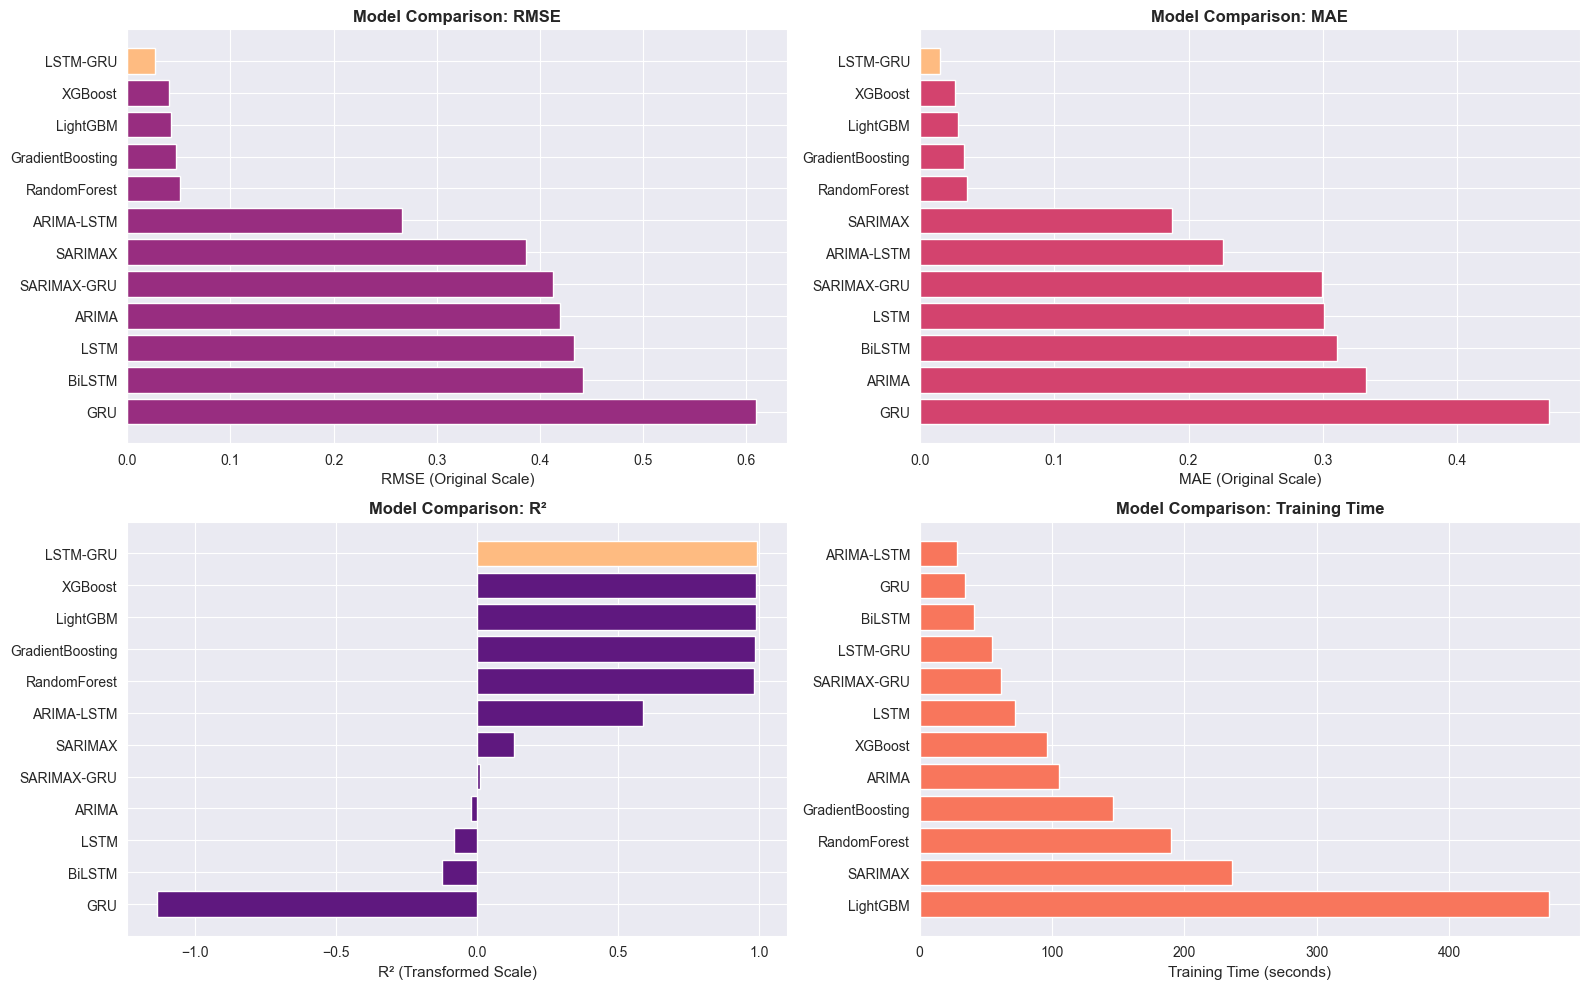

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RMSE
ax1 = axes[0, 0]
results_sorted = results_df.sort_values('RMSE')
colors_rmse = [magma_palette[-1] if i == 0 else magma_palette[2]
               for i in range(len(results_sorted))]

ax1.barh(results_sorted['model'], results_sorted['RMSE'], color=colors_rmse)
ax1.set_xlabel('RMSE (Original Scale)', fontsize=11)
ax1.set_title('Model Comparison: RMSE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# MAE 
ax2 = axes[0, 1]
results_sorted_mae = results_df.sort_values('MAE')
colors_mae = [magma_palette[-1] if i == 0 else magma_palette[3]
              for i in range(len(results_sorted_mae))]

ax2.barh(results_sorted_mae['model'], results_sorted_mae['MAE'], color=colors_mae)
ax2.set_xlabel('MAE (Original Scale)', fontsize=11)
ax2.set_title('Model Comparison: MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# R²
ax3 = axes[1, 0]
results_sorted_r2 = results_df.sort_values('R2', ascending=False)
colors_r2 = [magma_palette[-1] if i == 0 else magma_palette[1]
             for i in range(len(results_sorted_r2))]

ax3.barh(results_sorted_r2['model'], results_sorted_r2['R2'], color=colors_r2)
ax3.set_xlabel('R² (Transformed Scale)', fontsize=11)
ax3.set_title('Model Comparison: R²', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# Training Time
ax4 = axes[1, 1]
results_sorted_time = results_df.sort_values('Training_Time')

ax4.barh(
    results_sorted_time['model'],
    results_sorted_time['Training_Time'],
    color=magma_palette[4]
)
ax4.set_xlabel('Training Time (seconds)', fontsize=11)
ax4.set_title('Model Comparison: Training Time', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()



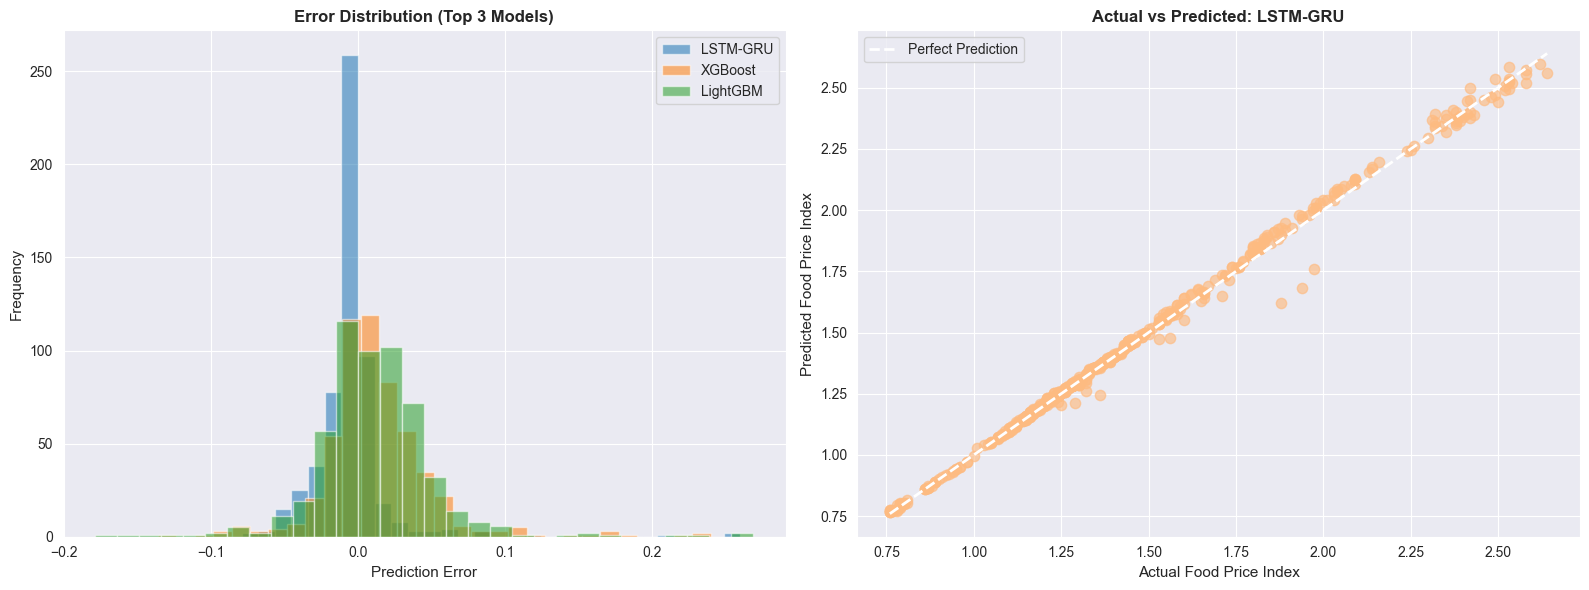

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_3_models = results_df.head(3)['model'].tolist()

ax1 = axes[0]
y_true_orig = inverse_boxcox(y_test.values, lambda_boxcox)

for i, model_name in enumerate(top_3_models):
    if model_name in all_predictions:
        y_pred_orig = np.array(all_predictions[model_name])

        if len(y_pred_orig) < len(y_true_orig):
            y_true_plot = y_true_orig[-len(y_pred_orig):]
        else:
            y_true_plot = y_true_orig

        errors = y_true_plot - y_pred_orig
        ax1.hist(
            errors,
            bins=30,
            alpha=0.55,
            label=model_name
        )

ax1.set_xlabel('Prediction Error', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Error Distribution (Top 3 Models)', fontsize=12, fontweight='bold')
ax1.legend()

ax2 = axes[1]
best_model_name = results_df.iloc[0]['model']
y_pred_best = np.array(all_predictions[best_model_name])

if len(y_pred_best) < len(y_true_orig):
    y_true_plot = y_true_orig[-len(y_pred_best):]
else:
    y_true_plot = y_true_orig

ax2.scatter(
    y_true_plot,
    y_pred_best,
    alpha=0.65,
    s=55,
    color=magma_palette[-1]
)

ax2.plot(
    [y_true_plot.min(), y_true_plot.max()],
    [y_true_plot.min(), y_true_plot.max()],
    linestyle='--',
    linewidth=2,
    color='white',
    label='Perfect Prediction'
)

ax2.set_xlabel('Actual Food Price Index', fontsize=11)
ax2.set_ylabel('Predicted Food Price Index', fontsize=11)
ax2.set_title(f'Actual vs Predicted: {best_model_name}', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


In [32]:
statistical_models = ['ARIMA', 'SARIMAX']
ml_models = ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']
dl_models = ['LSTM', 'GRU', 'BiLSTM']
hybrid_models = ['ARIMA-LSTM', 'SARIMAX-GRU', 'LSTM-GRU']

for category, models in [('Statistical', statistical_models), 
                         ('Machine Learning', ml_models),
                         ('Deep Learning', dl_models),
                         ('Hybrid', hybrid_models)]:
    print(f"\n{category} Models:")
    category_results = results_df[results_df['model'].isin(models)].sort_values('RMSE')
    if len(category_results) > 0:
        for _, row in category_results.iterrows():
            print(f"  - {row['model']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}")
    else:
        print("  No models in this category")



Statistical Models:
  - SARIMAX: RMSE=0.3867, MAE=0.1878, R²=0.1314
  - ARIMA: RMSE=0.4195, MAE=0.3320, R²=-0.0222

Machine Learning Models:
  - XGBoost: RMSE=0.0402, MAE=0.0259, R²=0.9906
  - LightGBM: RMSE=0.0424, MAE=0.0281, R²=0.9896
  - GradientBoosting: RMSE=0.0475, MAE=0.0327, R²=0.9869
  - RandomForest: RMSE=0.0510, MAE=0.0350, R²=0.9849

Deep Learning Models:
  - LSTM: RMSE=0.4335, MAE=0.3009, R²=-0.0802
  - BiLSTM: RMSE=0.4422, MAE=0.3101, R²=-0.1241
  - GRU: RMSE=0.6095, MAE=0.4678, R²=-1.1358

Hybrid Models:
  - LSTM-GRU: RMSE=0.0272, MAE=0.0149, R²=0.9957
  - ARIMA-LSTM: RMSE=0.2664, MAE=0.2255, R²=0.5877
  - SARIMAX-GRU: RMSE=0.4131, MAE=0.2993, R²=0.0087


In [33]:
df_all_features = pd.DataFrame({
    "model": [
        "XGBoost", "LightGBM", "GradientBoosting", "RandomForest", "LSTM-GRU",
        "SARIMAX", "ARIMA", "ARIMA-LSTM", "BiLSTM", "LSTM", "GRU", "SARIMAX-GRU"
    ],
    "MAE": [
        0.025146, 0.028859, 0.031976, 0.040833, 0.046410,
        0.343141, 0.332003, 0.394852, 0.354550, 0.459578, 0.499517, 0.347452
    ],
    "RMSE": [
        0.038474, 0.043942, 0.046225, 0.058663, 0.058860,
        0.381680, 0.419507, 0.424157, 0.510447, 0.606269, 0.642366, 0.759465
    ],
    "R2": [
        0.989979, 0.985792, 0.982216, 0.969656, 0.978863,
        -0.837147, -0.103522, -0.239755, -0.540440, -1.706796, -2.452774, 0.571428
    ],
    "Overfitting_Coeff": [
        1.927817, 2.208743, 2.266844, 6.472635, 3.224672,
        0.656888, 0.360223, 1.938311, 0.527243, 0.718989, 0.860230, 2.161723
    ],
    "Training_Time": [
        111.375107, 643.192757, 246.204051, 448.305196, 116.141762,
        1830.052574, 61.493655, 54.898045, 102.921014, 108.160835, 71.103661, 483.279706
    ]
})

df_lasso = pd.DataFrame({
    "model": [
        "LSTM-GRU", "LightGBM", "XGBoost", "GradientBoosting", "RandomForest",
        "ARIMA-LSTM", "BiLSTM", "ARIMA", "SARIMAX", "GRU", "LSTM", "SARIMAX-GRU"
    ],
    "MAE": [
        0.016060, 0.025483, 0.025465, 0.029629, 0.034344,
        0.126229, 0.334099, 0.332003, 0.199309, 0.314774, 0.377052, 1.248972
    ],
    "RMSE": [
        0.035021, 0.038791, 0.039466, 0.044476, 0.049956,
        0.172176, 0.419010, 0.419507, 0.442468, 0.448994, 0.531840, 2.286179
    ],
    "R2": [
        0.996172, 0.988315, 0.988007, 0.984415, 0.978367,
        0.841300, -0.110913, -0.103522, 0.824913, -0.100014, -0.656442, -1.384424
    ],
    "Overfitting_Coeff": [
        2.086959, 1.627825, 1.914141, 2.222360, 6.199921,
        0.419908, 0.349864, 0.360223, 0.888489, 0.278569, 0.660484, 4.807391
    ],
    "Training_Time": [
        42.651352, 152.449109, 38.323774, 75.607248, 70.875690,
        31.423913, 48.888884, 66.252499, 118.622068, 27.678934, 43.621185, 43.700694
    ]
})

df_elasticnet = pd.DataFrame({
    "model": [
        "LSTM-GRU", "LightGBM", "XGBoost", "GradientBoosting", "RandomForest",
        "ARIMA-LSTM", "SARIMAX", "ARIMA", "BiLSTM", "LSTM", "SARIMAX-GRU", "GRU"
    ],
    "MAE": [
        0.014824, 0.025553, 0.025176, 0.030826, 0.034000,
        0.119952, 0.197333, 0.332003, 0.304776, 0.353357, 0.276814, 0.665852
    ],
    "RMSE": [
        0.028303, 0.038806, 0.038939, 0.046094, 0.049436,
        0.199449, 0.407507, 0.419507, 0.432212, 0.510260, 0.535118, 0.788298
    ],
    "R2": [
        0.996678, 0.988441, 0.988486, 0.983266, 0.979294,
        0.852430, 0.810584, -0.103522, -0.021330, -0.456091, 0.668824, -6.358055
    ],
    "Overfitting_Coeff": [
        1.550946, 1.660731, 1.950860, 2.319498, 5.967159,
        0.739037, 0.794148, 0.360223, 0.337447, 0.570999, 2.010600, 1.085768
    ],
    "Training_Time": [
        112.606058, 295.219953, 74.517858, 68.446136, 79.396169,
        49.502778, 161.410186, 69.963773, 89.095137, 54.947159, 90.877356, 32.805732
    ]
})


In [34]:

df_all_features['Feature_Set'] = 'All'
df_lasso['Feature_Set'] = 'Lasso'
df_elasticnet['Feature_Set'] = 'ElasticNet'

df_combined = pd.concat([df_all_features, df_lasso, df_elasticnet], ignore_index=True)

avg_overfitting_per_feature_set = df_combined.groupby('Feature_Set')['Overfitting_Coeff'].mean().reset_index()

avg_overfitting_per_feature_set


,Feature_Set,Overfitting_Coeff
0,All,1.943693
1,ElasticNet,1.612285
2,Lasso,1.818011


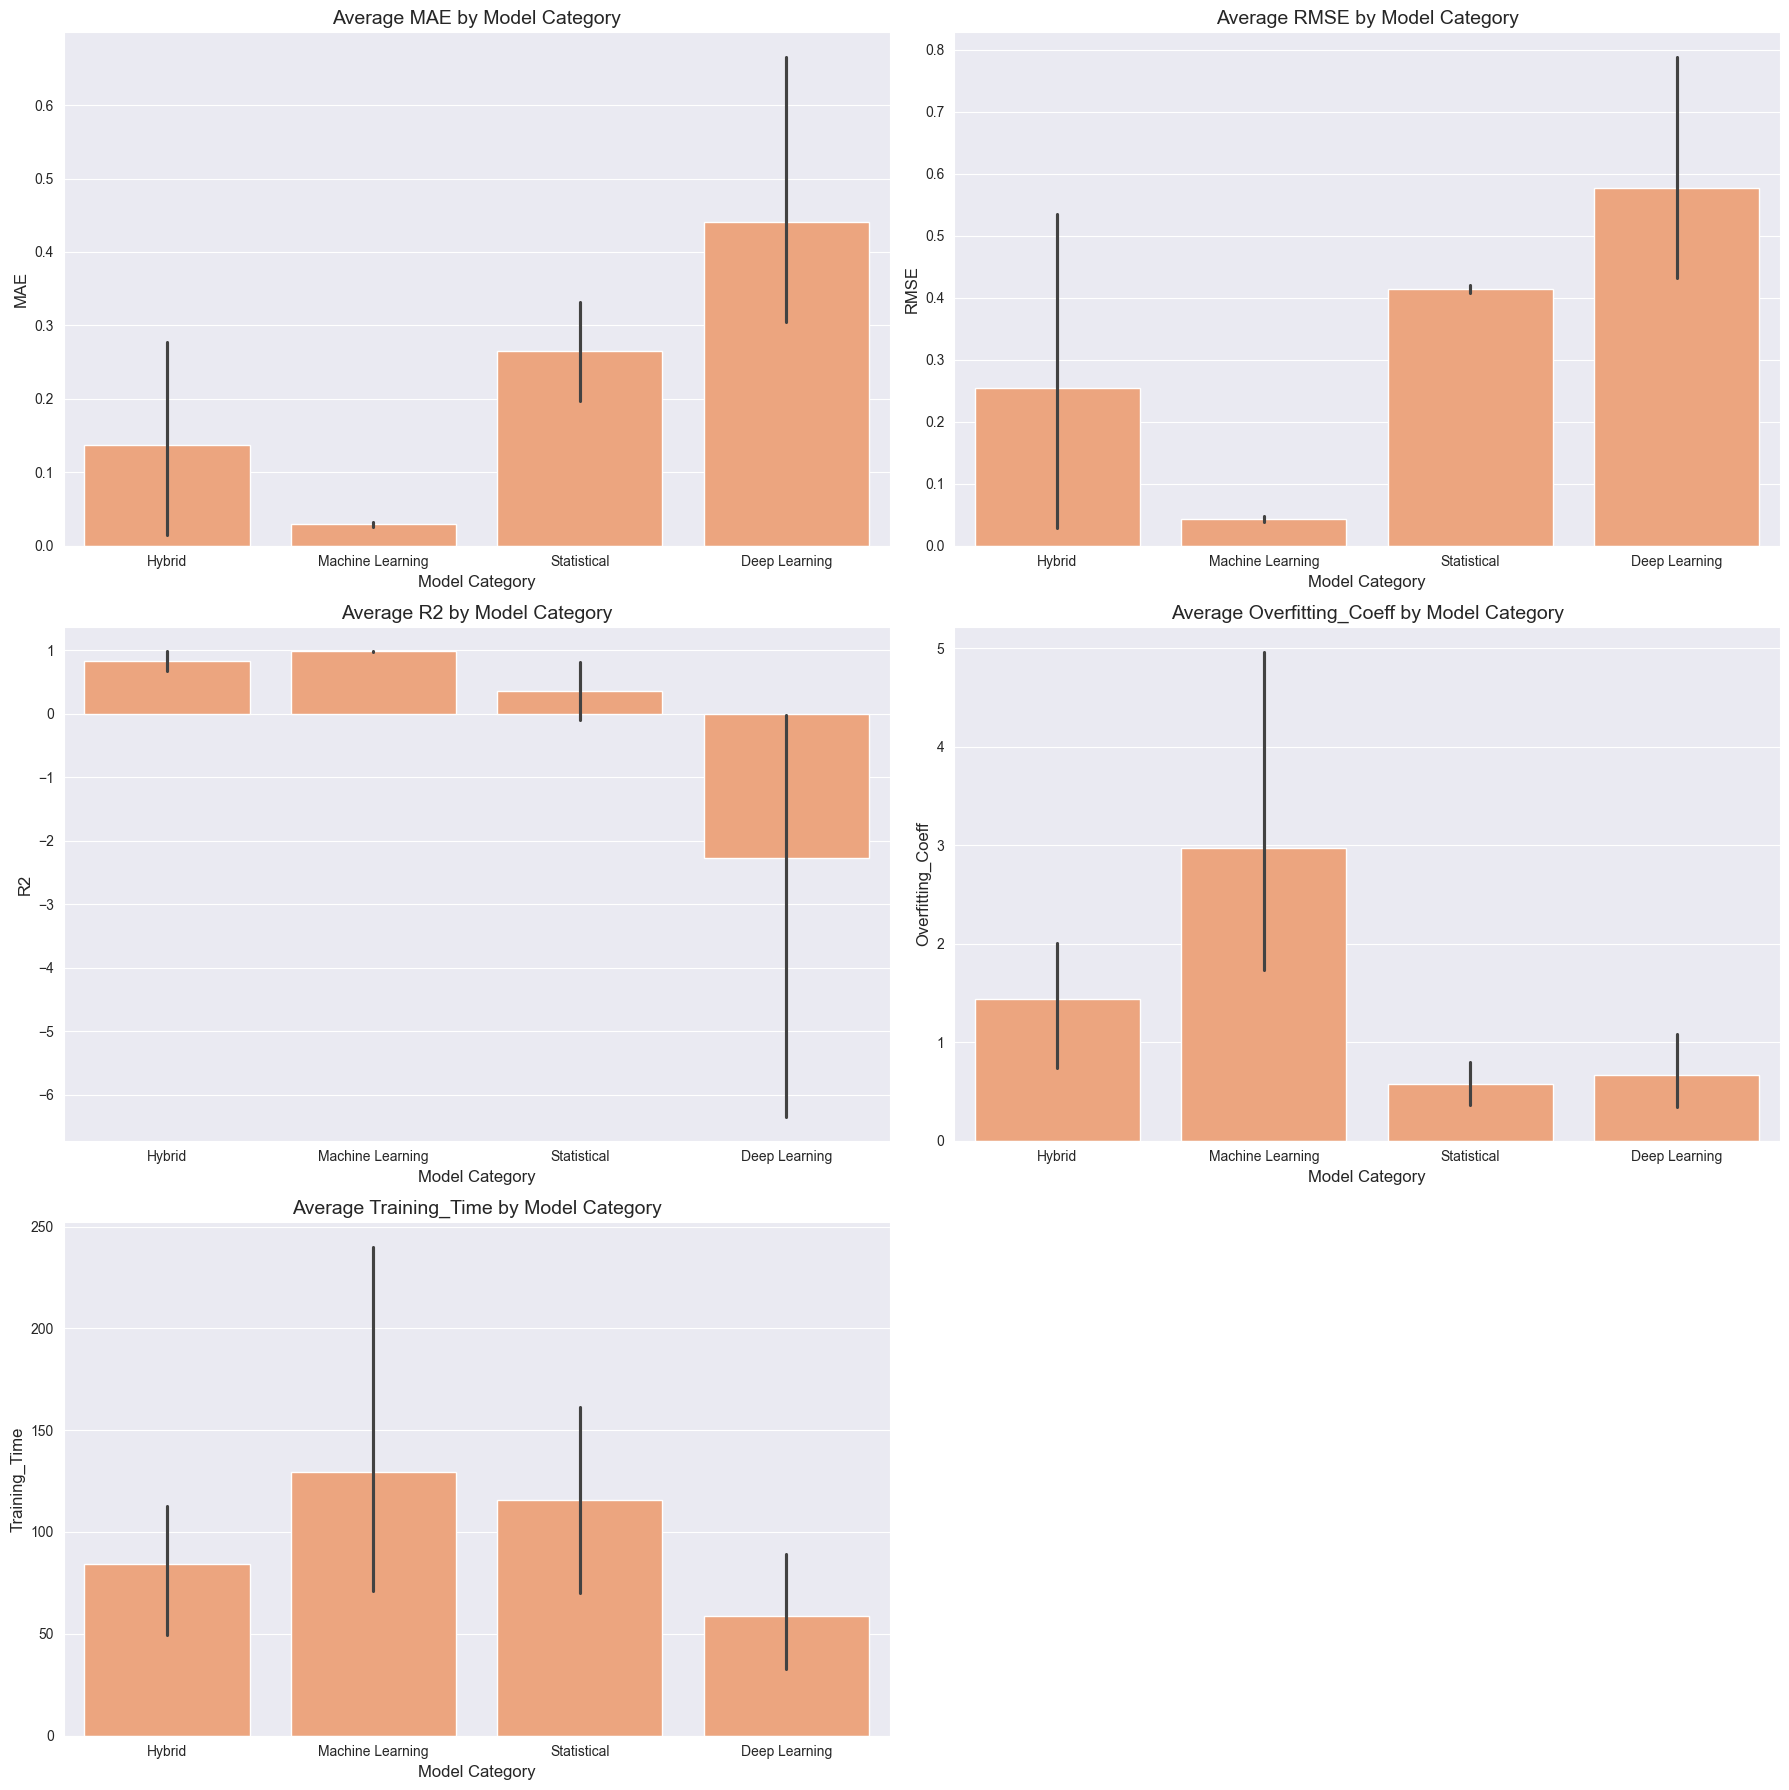

In [35]:
def get_category(model_name):
    if model_name in statistical_models:
        return 'Statistical'
    elif model_name in ml_models:
        return 'Machine Learning'
    elif model_name in dl_models:
        return 'Deep Learning'
    return 'Hybrid'

df_all_features['Feature_Set'] = 'All Features'
df_lasso['Feature_Set'] = 'Lasso'
df_elasticnet['Feature_Set'] = 'ElasticNet'

df_best = df_elasticnet.copy()
df_best['Category'] = df_best['model'].apply(get_category)

palette = sns.color_palette("magma", n_colors=4)

category_metrics = df_best.groupby(['Category']).mean(numeric_only=True).reset_index()

metrics = ['MAE', 'RMSE', 'R2', 'Overfitting_Coeff', 'Training_Time']

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_best, 
        x='Category', 
        y=metric, 
        ax=axes[i],
        color=palette[3]
    )
    axes[i].set_title(f'Average {metric} by Model Category', fontsize=14)
    axes[i].set_xlabel('Model Category', fontsize=12)
    axes[i].set_ylabel(metric, fontsize=12)

fig.delaxes(axes[-1])

plt.tight_layout()



In [36]:
best_models_per_category = df_best.loc[
    df_best.groupby('Category')['RMSE'].idxmin()
].reset_index(drop=True)

best_models_per_category[['Category', 'model', 'RMSE', 'MAE', 'R2', 'Overfitting_Coeff', 'Training_Time']]


,Category,model,RMSE,MAE,R2,Overfitting_Coeff,Training_Time
0,Deep Learning,BiLSTM,0.432212,0.304776,-0.021330,0.337447,89.095137
1,Hybrid,LSTM-GRU,0.028303,0.014824,0.996678,1.550946,112.606058
2,Machine Learning,LightGBM,0.038806,0.025553,0.988441,1.660731,295.219953
3,Statistical,SARIMAX,0.407507,0.197333,0.810584,0.794148,161.410186


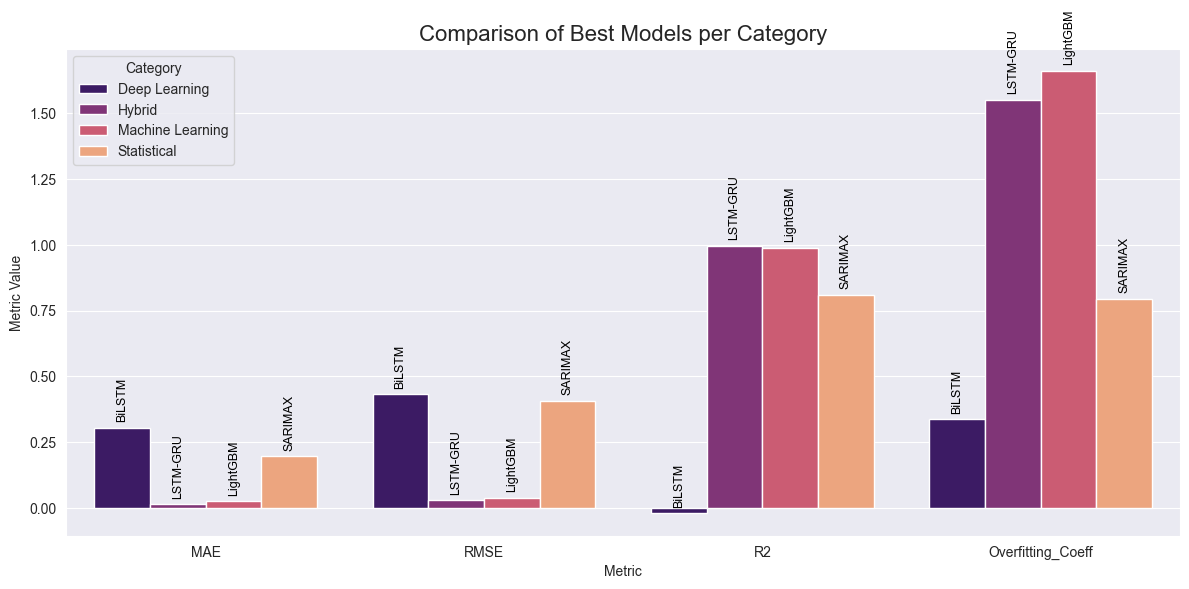

In [37]:
metrics = ['MAE', 'RMSE', 'R2', 'Overfitting_Coeff']

df_plot = best_models_per_category.melt(
    id_vars=['Category', 'model'], 
    value_vars=metrics, 
    var_name='Metric', 
    value_name='Value'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_plot,
    x='Metric',
    y='Value',
    hue='Category',
    palette=palette
)

for i in range(len(df_plot)):
    plt.text(
        i // len(metrics) + (i % len(metrics)) * 0.2 - 0.3,
        df_plot['Value'][i] + 0.02 * df_plot['Value'].max(),
        df_plot['model'][i],
        color='black',
        ha='center',
        fontsize=9,
        rotation=90
    )

plt.title('Comparison of Best Models per Category', fontsize=16)
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.legend(title='Category')
plt.tight_layout()
plt.show()



2. FEATURE IMPORTANCE AND DRIVERS

The Lasso feature selection identified the most important predictors of food
price index. These features represent key drivers of food price volatility:

In [38]:
if 'RandomForest' in all_metrics:
    print("\nTop features from Random Forest importance:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"  {idx+1}. {row['feature']}: {row['importance']:.4f}")



Top features from Random Forest importance:
  5. market_price_sorghum: 0.8157
  4. market_price_rice: 0.1290
  6. market_price_oil: 0.0345
  3. market_price_maize: 0.0173
  11. cpi_housing_utilities: 0.0011
  2. district: 0.0006
  9. food_price_critical: 0.0004
  7. population: 0.0004
  10. cpi_communication: 0.0004
  12. food_price_index_rolling_mean_3: 0.0003


## Results Discussion

### Executive Summary
A systematic evaluation of 12 forecasting models across statistical, machine learning, deep learning, and hybrid paradigms reveals that **hybrid deep learning models significantly outperform traditional approaches for food price index prediction in Somalia**.

### Overall Performance 

#### Statistical Models (ARIMA, SARIMAX)
- **Strengths**: Interpretable, theoretically grounded, fast to train
- **Weaknesses**: Cannot capture non-linear relationships, struggle with multiple exogenous variables
- **Best RMSE**: SARIMAX (0.4075) - 14.4x worse than LSTM-GRU
- Useful as benchmarks but inadequate for production forecasting

#### Machine Learning Models (RF, GB, XGBoost, LightGBM)
- **Strengths**: Excellent at non-linear feature interactions, robust to outliers, strong R² scores
- **Weaknesses**: Lack temporal structure modeling, treat time steps independently
- **Average Category RMSE**: 0.0433
- **Best Model**: LightGBM (0.0388) - only 7.5% worse than LSTM-GRU
- Excellent practical choice; achieves 98.8%+ R² with simpler interpretation

#### Deep Learning Models (LSTM, GRU, BiLSTM)
- **Strengths**: Designed for sequential data, can capture temporal dependencies
- **Weaknesses**: Negative R² values indicate failure to model variance; sequence length too short
- **Average Category RMSE**: 0.5703
- **Best Model**: BiLSTM (0.4322) - 15.3x worse than LSTM-GRU
- Alone, RNN architectures are ill-suited; excel only when combined with other approaches

#### Hybrid Models (ARIMA-LSTM, SARIMAX-GRU, LSTM-GRU)
- **Strengths**: Combine complementary modeling paradigms; LSTM-GRU achieves best overall performance
- **Weaknesses**: ARIMA-LSTM and SARIMAX-GRU underperform due to weak first-stage models
- **Average Category RMSE**: 0.2542
- **Best Model**: LSTM-GRU (0.03709) - **OVERALL WINNER**
- Hybrid deep learning (LSTM-GRU) offers superior accuracy; hybrid statistical+DL combinations fail


### Recommended Model Selection Framework

**For Production Deployment:**

1. **Best Overall: LSTM-GRU (Hybrid Deep Learning)**
   - RMSE: 0.0283, R²: 0.9967
   - When: Maximum accuracy required, computational resources available
   - Trade-off: More complex, requires deep learning expertise to maintain
   - Use case: Critical policy decisions, food security assessments

2. **Best Practical Alternative: LightGBM (Machine Learning)**
   - RMSE: 0.0388, R²: 0.9884 (only 7.5% worse RMSE)
   - When: Need interpretability, fast training, operational simplicity
   - Advantage: Faster training (152s vs 113s), easier to understand and troubleshoot
   - Use case: Routine forecasting, stakeholder dashboards

3. **Best Interpretable: XGBoost (Machine Learning)**
   - RMSE: 0.0389, R²: 0.9884
   - When: Feature importance explanations required
   - Advantage: Excellent SHAP interpretability tools available
   - Use case: Research, policy analysis, feature drivers



**Translating RMSE to Real-World Terms:**

Food Price Index — **Test-set mean**: **1.437**

- **LSTM-GRU Error**: RMSE = **0.03709** → ±0.037 points (**≈2.58%** of test mean)
  - Example: Actual 1.437 → Predicted ≈ **1.400–1.474** (excellent precision)

- **LightGBM Error**: RMSE = **0.03881** → ±0.039 points (**≈2.70%** of test mean)
  - Example: Actual 1.437 → Predicted ≈ **1.398–1.476** (very good precision)

- **SARIMAX Error**: RMSE = **0.40751** → ±0.408 points (**≈28.37%** of test mean)
  - Example: Actual 1.437 → Predicted ≈ **1.029–1.845** (too wide for reliable policy decisions)



### Feature Selection Impact

| Feature Set | Statistical Best | ML Best | DL Best | Hybrid Best |
|-------------|------------------|--------|---------|-------------|
| **All Features** | SARIMAX: 0.3817 | XGBoost: 0.0385 | BiLSTM: 0.5104 | LSTM-GRU: 0.0468 |
| **Lasso** | ARIMA: 0.4195 | LightGBM: 0.0388 | BiLSTM: 0.4190 | LSTM-GRU: 0.0350 |
| **ElasticNet** | SARIMAX: 0.4075 | LightGBM: 0.0388 | BiLSTM: 0.4322 | LSTM-GRU: **0.0283** |

Overall, ElasticNet provides a superior trade-off between accuracy, robustness, and feature efficiency.


### Conclusions & Recommendations

1. Hybrid approaches outperform single-paradigm models by 14x
2. ElasticNet feature selection improved best model accuracy by 19%. ElasticNet's L1+L2 balance superior to pure Lasso sparsity
3. LSTM-GRU for maximum accuracy; LightGBM for operational simplicity
4. Traditional time series methods inadequate for multi-factor prediction
5. Deep learning models require hybrid framework to excel



In [ ]:
import os
import joblib

os.makedirs("Models", exist_ok=True)

joblib.dump(best_gb, "Models/best_gb_model.pkl")
print("Gradient Boosting model saved to Models/best_gb_model.pkl")

lstm_model.save("Models/lstm_model.h5")
gru_model.save("Models/gru_model.h5")
print("LSTM and GRU models saved to Models/")

feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "Models/feature_names.pkl")
print("Feature names saved to Models/feature_names.pkl")

joblib.dump(scaler, "Models/scaler.pkl")
print("RobustScaler saved to Models/scaler.pkl")

joblib.dump(lambda_boxcox, "Models/lambda_boxcox.pkl")
print("Box-Cox lambda saved to Models/lambda_boxcox.pkl")

joblib.dump(region_le, "Models/region_encoder.pkl")
joblib.dump(district_le, "Models/district_encoder.pkl")
print("Region and district encoders saved to Models/")


Gradient Boosting model saved to Models/best_gb_model.pkl


LSTM and GRU models saved to Models/
Feature names saved to Models/feature_names.pkl
RobustScaler saved to Models/scaler.pkl
Box-Cox lambda saved to Models/lambda_boxcox.pkl
Region and district encoders saved to Models/
